Using DBSCAN

In [1]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

In [2]:
x,y=make_moons(
    n_samples=500,
    noise=0.1,
    random_state=42)

In [3]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

<Axes: >

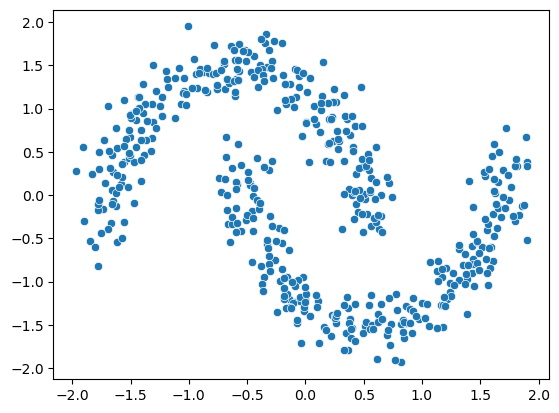

In [4]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1])

In [6]:
dbscan=DBSCAN(
    eps=0.2,
    min_samples=5)
lables=dbscan.fit_predict(x_scaled)

<Axes: >

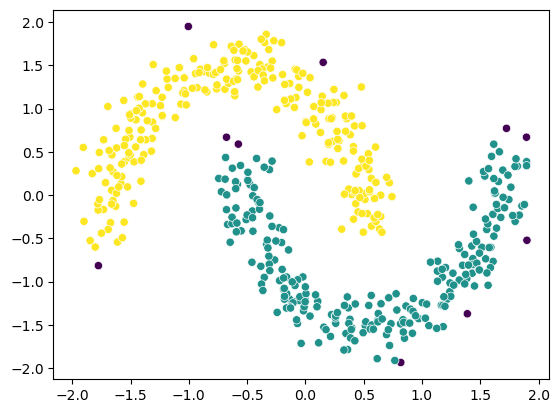

In [9]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1],c=lables)

Using Isolation Forest

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [13]:
df=pd.read_csv("thyroid_dataset.csv")

In [14]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [16]:
x=df.drop("Outlier_label",axis=1)
y=df["Outlier_label"]

In [17]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [30]:
from sklearn.ensemble import IsolationForest

In [31]:
clf=IsolationForest(n_estimators=200,contamination='auto',random_state=42)

In [32]:
labels=clf.fit_predict(x_scaled)

In [33]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

Text(0, 0.5, 'PC2')

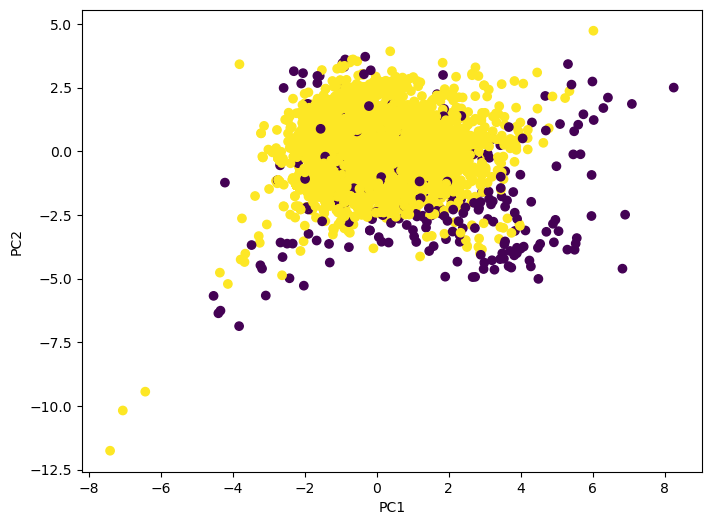

In [36]:
plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0],x_pca[:,1],c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [26]:
import numpy as np
n_outliers=np.sum(labels==-1)
n_normal=np.sum(labels==1)
print("outlier:",n_outliers)
print("normal:",n_normal)

outlier: 270
normal: 6646


Using LOF

In [27]:
from sklearn.neighbors import LocalOutlierFactor
neighbs=LocalOutlierFactor()
labels=neighbs.fit_predict(x_scaled)

Text(0, 0.5, 'PC2')

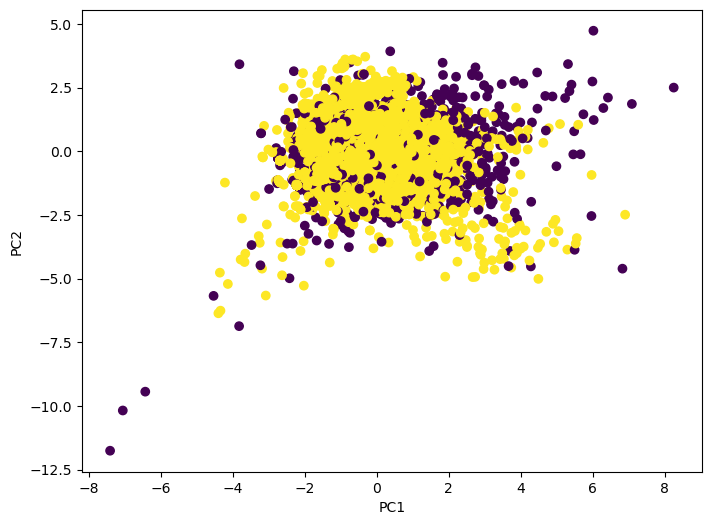

In [28]:
plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0],x_pca[:,1],c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [29]:
n_outliers=np.sum(labels==-1)
n_normal=np.sum(labels==1)
print("outlier:",n_outliers)
print("normal:",n_normal)

outlier: 883
normal: 6033
